In [2]:
import numpy as np
from matplotlib import pyplot as plt
import pickle
import os, sys
import torch
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from collections import defaultdict
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap, BoundaryNorm

# Root project
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)

from envs import *
from basal_ganglia import *
from stn_gpe import *

# filter warnings
import warnings
warnings.filterwarnings("ignore")



plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # Times for publication
    "font.size": 9,                    # Base font size
    "axes.labelsize": 9,              # Axis label font size
    "axes.labelweight": "bold",
    "font.weight": "bold",   
    "axes.titlesize":8,              # Axis title (not fig title)
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize":8,              # Legend font size

    "figure.dpi": 300,                 # Display resolution
    "savefig.dpi": 300,                # Save resolution
    "figure.constrained_layout.use": True,  # Better spacing than tight_layout

    "axes.linewidth": 0.8,             # Thin but clear axes lines
    "lines.linewidth": 1.2,
    "lines.markersize": 5,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,

    "legend.frameon": False,
    "legend.handlelength": 2.0,        # Slightly longer legend lines
    "legend.handletextpad": 0.5,

    "pdf.fonttype": 42,                # Embed editable fonts in PDF
    "ps.fonttype": 42
})

import pickle


Project root added to sys.path: /Users/charithapalika/Desktop/Lab projects/Decision Making/Light_House_DBS/light_house_DBS_decision_making


In [3]:
lat_arr = [0.0275, 0.0325, 0.0375, 0.0425, 0.0475]
del_lim_arr = [0.1, 0.2, 0.5, 1.0]
last_bin_PD_all = []
last_bin_std_DBS_all = []
last_bin_sector_DBS_all = []

for i in range(len(lat_arr)):
    lat_str = str(lat_arr[i]).replace('.', '_')
    
    data_file = os.path.join(project_root, 'results', 'decision_making_tasks', 'data', 'non_stationary_bandits', 'non_stationary_bandits_data_lat_'+ lat_str + '.pkl')
    with open(data_file, 'rb') as f:
      data = pickle.load(f)
    del_lim_arr = data['DEL_LIM_ARR']
    lat_strength = data['LAT_STRENGTH']
    last_bin_prob_monitor = data['LAST_BIN_PROB_MONITOR']

    Last_bin_Probs_PD = [last_bin_prob_monitor['PD'][del_lim] for del_lim in del_lim_arr]
    Last_bin_Probs_std_DBS = [last_bin_prob_monitor['STD_DBS'][del_lim] for del_lim in del_lim_arr]
    Last_bin_Probs_sector_DBS = [last_bin_prob_monitor['SECTOR_DBS'][del_lim] for del_lim in del_lim_arr]

    last_bin_PD_all.append(Last_bin_Probs_PD)
    last_bin_std_DBS_all.append(Last_bin_Probs_std_DBS)
    last_bin_sector_DBS_all.append(Last_bin_Probs_sector_DBS)
        

In [25]:
colors = {'normal':"#054b7c",
          'PD': "#9f0d03ff",
          'std_DBS': "#ad7322",
          'sector_DBS': "#038820",}

colors_PD_shades = ['#C84B3A', '#B33624', '#9F0D03', '#7E0A02', '#5A0601']
colors_std_shades = ['#F2CF9F', '#E0A85C', '#C97A30', '#AD7322', '#7F4A10'] # light -> dark (mid-tone start)
colors_sector_shades = ['#A7E3B9', '#6ED69A', '#2FBF6E', '#038820', '#006012'] # light -> dark (somewhat lighter start)
# colors_PD_shades = ['#EAAFA5', '#D36A4B', '#B73A22', '#9F0D03', '#6E0602'] # light -> dark (somewhat lighter start)

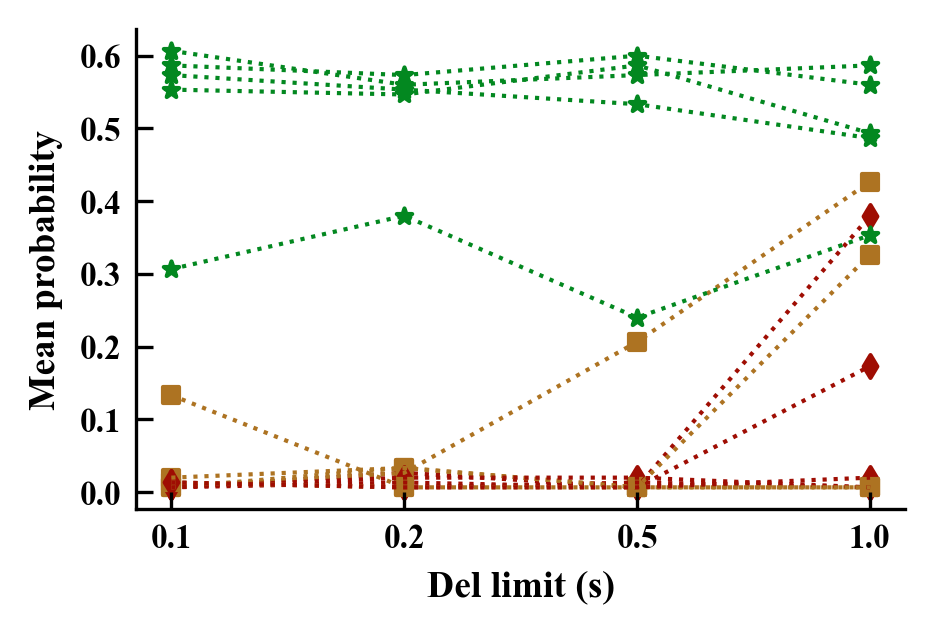

In [32]:
plt.figure(figsize=(3, 2))
for i in range(5):
    plt.scatter(np.arange(4), last_bin_PD_all[i], marker='d', color=colors['PD'], s=15)
    plt.scatter(np.arange(4), last_bin_std_DBS_all[i], marker='s', color=colors['std_DBS'], s=15)
    plt.scatter(np.arange(4), last_bin_sector_DBS_all[i], marker='*', color=colors['sector_DBS'], s=15)
    plt.plot(np.arange(4), last_bin_PD_all[i], color=colors['PD'], linewidth=1, alpha=1, linestyle='dotted')
    plt.plot(np.arange(4), last_bin_std_DBS_all[i], color=colors['std_DBS'], linewidth=1, alpha=1, linestyle='dotted')
    plt.plot(np.arange(4), last_bin_sector_DBS_all[i], color=colors['sector_DBS'], linewidth=1, alpha=1, linestyle='dotted')
    plt.xlabel('Del limit (s)')
    plt.ylabel('Mean probability')
    plt.xticks(np.arange(4), del_lim_arr)
